# Crowd Level Classification (Advanced)
Includes Hyperparameter Tuning + Confusion Matrix

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [2]:
# Load dataset
df = pd.read_csv('alert_data.csv')

# Encode labels
le = LabelEncoder()
df['Alert'] = le.fit_transform(df['Alert'])

X = df[['Total_Count', 'Density']]
y = df['Alert']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 🔥 Hyperparameter Tuning (Random Forest)

In [3]:
rf = RandomForestClassifier()

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(rf, param_grid, cv=3, scoring='accuracy')
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print("Best Parameters:", grid.best_params_)


Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


## 🧠 Train All Models

In [4]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest (Tuned)": best_rf,
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    })

results_df = pd.DataFrame(results)
results_df


C:\Users\Admin\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [17:31:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Decision Tree,1.0,1.0,1.0,1.0
2,Random Forest (Tuned),1.0,1.0,1.0,1.0
3,XGBoost,1.0,1.0,1.0,1.0


## 📊 Model Comparison Graph

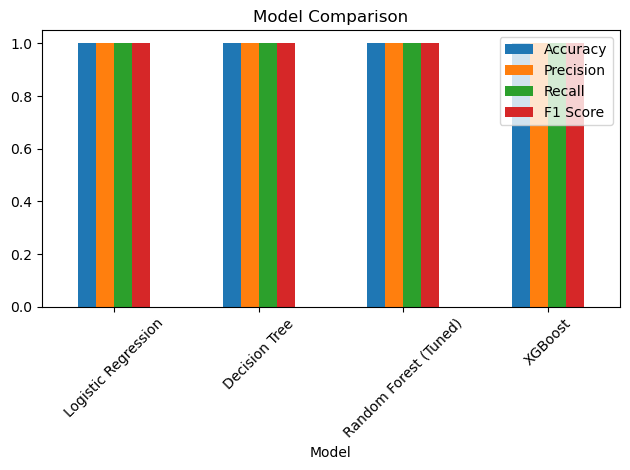

In [5]:
results_df.set_index('Model')[['Accuracy','Precision','Recall','F1 Score']].plot(kind='bar')
plt.title("Model Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 🔍 Confusion Matrix (Best Model)

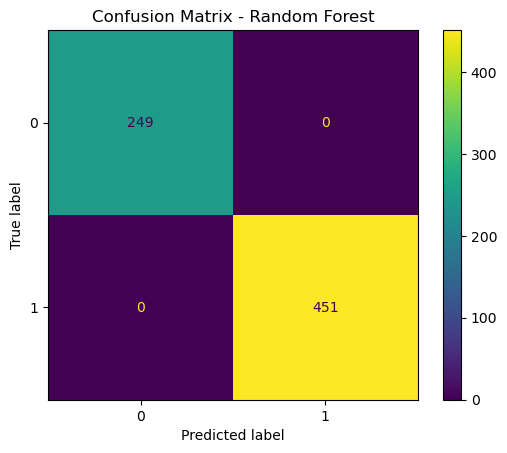

In [6]:
# Use best model (Random Forest tuned)
y_pred = best_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()


In [7]:
import pickle

# Save the model
with open("alert_model.pkl", "wb") as f:
    pickle.dump(best_rf, f)

print("Model saved successfully ✅")

Model saved successfully ✅
